**1**) **İmport** **Etmek**

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
%matplotlib inline

**2)** **Dosya Çağırma**

In [4]:
df = pd.read_csv('laptopPrice.csv')

In [5]:
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,ASUS,Intel,Core i5,10th,8 GB,DDR4,512 GB,0 GB,Windows,32-bit,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,ASUS,Intel,Celeron Dual,Not Available,4 GB,DDR4,0 GB,512 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   brand              823 non-null    object
 1   processor_brand    823 non-null    object
 2   processor_name     823 non-null    object
 3   processor_gnrtn    823 non-null    object
 4   ram_gb             823 non-null    object
 5   ram_type           823 non-null    object
 6   ssd                823 non-null    object
 7   hdd                823 non-null    object
 8   os                 823 non-null    object
 9   os_bit             823 non-null    object
 10  graphic_card_gb    823 non-null    object
 11  weight             823 non-null    object
 12  warranty           823 non-null    object
 13  Touchscreen        823 non-null    object
 14  msoffice           823 non-null    object
 15  Price              823 non-null    int64 
 16  rating             823 non-null    object
 1

**3)** **Objeleri Sayıya Çevirme**

In [7]:
df["ram_gb"] = df["ram_gb"].str.replace("GB","")
df["ram_gb"] = df["ram_gb"].astype(int)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   brand              823 non-null    object
 1   processor_brand    823 non-null    object
 2   processor_name     823 non-null    object
 3   processor_gnrtn    823 non-null    object
 4   ram_gb             823 non-null    int64 
 5   ram_type           823 non-null    object
 6   ssd                823 non-null    object
 7   hdd                823 non-null    object
 8   os                 823 non-null    object
 9   os_bit             823 non-null    object
 10  graphic_card_gb    823 non-null    object
 11  weight             823 non-null    object
 12  warranty           823 non-null    object
 13  Touchscreen        823 non-null    object
 14  msoffice           823 non-null    object
 15  Price              823 non-null    int64 
 16  rating             823 non-null    object
 1

**4) Objeleri Fonksiyon ile Sayıya Çevirme** ( *ÖNEMLİ* )

In [9]:
def df_cleaner(row, deleted_units):
    # 1. Adım: Sütundaki metni (örneğin " GB") bul ve sil
    clean_df = row.str.replace(deleted_units, "")

    # 2. Adım: Elimizde kalan sayı görünümlü metni gerçek sayıya çevir
    numeric_row = clean_df.astype(int)

    # 3. Adım: İşlenmiş sütunu makineden dışarı (geri) gönder
    return numeric_row

In [10]:
# SSD sütununu temizleyelim
df["ssd"] = df_cleaner(df["ssd"], " GB")

# HDD sütununu temizleyelim
df["hdd"] = df_cleaner(df["hdd"], " GB")

# Ekran kartı GB sütununu temizleyelim
df["graphic_card_gb"] = df_cleaner(df["graphic_card_gb"], " GB")

# Hatta ağırlık sütununda " kg" yazıyorsa onu da yapabilirsin
# df["weight"] = df_cleaner(df["weight"], " kg")

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   brand              823 non-null    object
 1   processor_brand    823 non-null    object
 2   processor_name     823 non-null    object
 3   processor_gnrtn    823 non-null    object
 4   ram_gb             823 non-null    int64 
 5   ram_type           823 non-null    object
 6   ssd                823 non-null    int64 
 7   hdd                823 non-null    int64 
 8   os                 823 non-null    object
 9   os_bit             823 non-null    object
 10  graphic_card_gb    823 non-null    int64 
 11  weight             823 non-null    object
 12  warranty           823 non-null    object
 13  Touchscreen        823 non-null    object
 14  msoffice           823 non-null    object
 15  Price              823 non-null    int64 
 16  rating             823 non-null    object
 1

**5) Korelasyon**

In [12]:
numeric_df = df.select_dtypes(include=["number"])

In [13]:
correlation_table = numeric_df.corr()

In [14]:
print(correlation_table)

                     ram_gb       ssd       hdd  graphic_card_gb     Price  \
ram_gb             1.000000  0.390703 -0.176682         0.278544  0.518323   
ssd                0.390703  1.000000 -0.589509         0.334424  0.628272   
hdd               -0.176682 -0.589509  1.000000        -0.058491 -0.252699   
graphic_card_gb    0.278544  0.334424 -0.058491         1.000000  0.459986   
Price              0.518323  0.628272 -0.252699         0.459986  1.000000   
Number of Ratings -0.113348 -0.164338  0.103361        -0.027118 -0.140392   
Number of Reviews -0.116811 -0.169160  0.113588        -0.021457 -0.148738   

                   Number of Ratings  Number of Reviews  
ram_gb                     -0.113348          -0.116811  
ssd                        -0.164338          -0.169160  
hdd                         0.103361           0.113588  
graphic_card_gb            -0.027118          -0.021457  
Price                      -0.140392          -0.148738  
Number of Ratings          

**6) Korelasyonu Heatmap Üzerinden Gösterme**

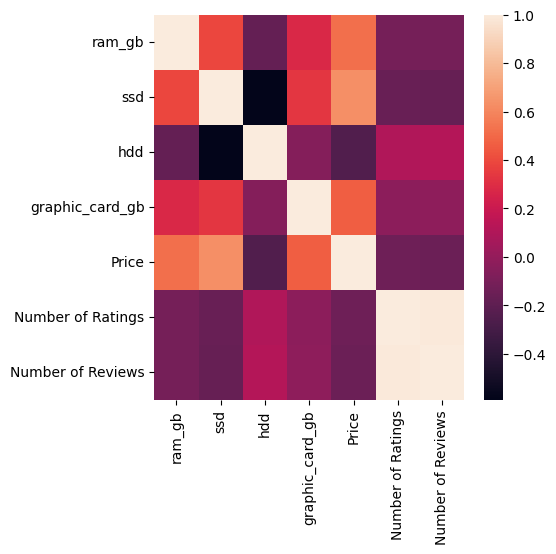

In [15]:
plt.figure(figsize = (5,5))
sns.heatmap(correlation_table)
plt.show()

#Burada renkler de koyular negatif korelasyon, açıklar ise pozitif korelasyonu temsil eder.
#Mesela y doğrusunun üzerindeki ram gb ile x kolonundaki ram gb kısmının kesişimi açıkrenklidir çünkü ram gb si arttıkça fiyatta artar ve ikiside aynı olduğu için korelasyon yüksektir.
#Neden hdd ve ssd kesişimleri en koyular. günümüzde ssd hdd ye göre daha hızlı ve dayanıklıdır. buda ssd arttıkça hdd nin fiyatının azalması anlamına gelmektedir
#Mantık tamamen bu şekildedir :)

**7) Encoding** ( *Hız için ÖNEMLİ* )

In [16]:
#Bilgisayarlar bildiğimiz üzere sayılarla çalışır. bizim yazdığımız ssd, hdd gibi harfli şeyler bize sıkıntı çıkarır.
#Bu sebeple "ENCODİNG" dediğimiz stringleri sayıya eşitlemeyi kullanırız. Ve bunun iki adet yöntemi vardır.
#Label encoding ve One hot encoding. bunların çalışma mantığı şu şekildedir ;
#Label Encoding: Her bir kelimeyi temsil etmesi için bi sayı belirle, örneğin: ssd 1, hdd 2, ram 3.
#Burada sistem şunu anlayanilir. ram 3 ise ozaman ssd ve hdd den üstündür. Bu yanlış bir çıkarımdır ve mümkündür
#Ama One Hot Encoding de ise bu iş biraz daha farklıdır. orada ssd evet ise 1 değilse 0, hdd evet ise 1 değil ise 0
#Bu mantıkla sistem mantıksal bi üstünlük kurmadan yoluna bakar

In [17]:
df = pd.get_dummies(df)

In [18]:
df.head()

,ram_gb,ssd,hdd,graphic_card_gb,Price,Number of Ratings,Number of Reviews,brand_APPLE,brand_ASUS,brand_Avita,...,warranty_No warranty,Touchscreen_No,Touchscreen_Yes,msoffice_No,msoffice_Yes,rating_1 star,rating_2 stars,rating_3 stars,rating_4 stars,rating_5 stars
0,4,0,1024,0,34649,3,0,False,True,False,...,True,True,False,True,False,False,True,False,False,False
1,4,0,1024,0,38999,65,5,False,False,False,...,True,True,False,True,False,False,False,True,False,False
2,4,0,1024,0,39999,8,1,False,False,False,...,True,True,False,True,False,False,False,True,False,False
3,8,512,0,2,69990,0,0,False,True,False,...,True,True,False,True,False,False,False,True,False,False
4,4,0,512,0,26990,0,0,False,True,False,...,True,True,False,True,False,False,False,True,False,False


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 64 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   ram_gb                         823 non-null    int64
 1   ssd                            823 non-null    int64
 2   hdd                            823 non-null    int64
 3   graphic_card_gb                823 non-null    int64
 4   Price                          823 non-null    int64
 5   Number of Ratings              823 non-null    int64
 6   Number of Reviews              823 non-null    int64
 7   brand_APPLE                    823 non-null    bool 
 8   brand_ASUS                     823 non-null    bool 
 9   brand_Avita                    823 non-null    bool 
 10  brand_DELL                     823 non-null    bool 
 11  brand_HP                       823 non-null    bool 
 12  brand_Lenovo                   823 non-null    bool 
 13  brand_MSI           

**8) Veriyi Bölme**

In [20]:
#Veriyi neden böleriz.Bunu sınav cevap olarak düşünebiliriz. X(Sorular) sınav kağıdındaki sorular, y(Cevap Anatarı)
#Eğer hoca sınavın yanında bide cevap anahtarını verseydi ne olurdu? mantık üretmeyi bırakıp direk kolaya yönelirdik
#Buna yapay zekada Sızıntı(Data Leakage) diyorlar. Bizim amacımız modelin sorulara(X) bakıp cevapı(y) kendi kendine tahmin etmeyi öğrenmesidir


In [21]:
y = df["Price"]

In [22]:
X = df.drop("Price", axis=1)

In [23]:
y.head()

,Price
0,34649
1,38999
2,39999
3,69990
4,26990


**9) Train-Test Split** ( *Önemli* )

In [24]:
#Soruları ve cevapları ayırdık. Ama bir sorun var: Eğer makineyi tüm sorularla eğitirsek, onu nasıl test edeceğiz?
#Kendi çözdüğü soruları tekrar sorarsak bu "ezber"(Overfitting) olur, gerçek başarıyı ölçemeyiz.

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
#Sklearn devasa bir kütüphanedir doğrudan import etmek yerine sadece train test spliti test etmek daha akıllıcadır

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
#random_state nedir? random_state veriyi eğitim ve test diye ikiye bölerken il önce veriyi karşıtırır.
#Eğer bu karıştırma işini şansa bırakırsak kodu herçalıştırdığımızda eğitim ve test verileri değişir ve bugün %90 başarı aldığımız veri yarın %26 ya bile inebilir
#Peki ya neden 42? aslında oraya yazacağımız herhangi bir sayı bu rastgelelik sıkıntısını çözer ama 42 kod dünyasındaki bir gelenektir.
#Douglas Adams'ın ünlü "Otostopçunun Galaksi Rehberi" kitabında, devasa bir bilgisayara "Hayat, Evren ve Her Şey'e
#dair nihai cevap" sorulur ve bilgisayar milyonlarca yıl hesaplama yaptıktan sonra şu cevabı verir: 42

**10) Modeli Sahneye Çıkartma**

In [29]:
#Daha öncede dediğim gibi sklearn koskocaman ve bize sadece kullanacağımız kısım yeter oda Lineer Regresyon(LinearRegression)

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
model = LinearRegression()

In [32]:
#.fit nedir? Bunu boks üzerinden açıklığa kavuşturalım. burada fit süreci rakibin hareketlerinden hamlesini çözme çabasıdır
#Veri(X): Rakibin omuz hareketleri, ayak pozisyonu ve gözünü kaçırması
#Sonuç(y): Rakibin atacağı sol kroşe
#Fit Süreci: biz rakibin antrenmanda veya maçın başından beri binlerce kez omuz hareketlerine bakıp, sonucun kroşe olup olmadığını gözlemleriz.
#Beynimiz bu iki olay arasındaki "matematiksel bağı" kurduğunda artık rakip omzunu kımıldattığı an yumruğun gelebileceğini tahmin edebiliriz.
#işte .fit budur özelliklerle sonuç arasındaki bağı sabitlemek...

In [33]:
model.fit(X_train, y_train)

LinearRegression()

In [34]:
#Matematiksel olarak arka planda dönen olay tamda aşağıdaki gibidir

$$Price = (w_1 \cdot RAM) + (w_2 \cdot SSD) + \dots + b$$

**11) Uygulama**

In [35]:
#Nedir bu coef_ ? Tamamı Coefficients olan kod, bizim modelin her bir donanım özelliği için belirlediği "Etki Gücü" dür
#Matematiksel karşılığı aşağıdaki gibidir;

**$$y = (w_1 \cdot x_1) + (w_2 \cdot x_2) + \dots + b$$**

In [36]:
#Buradaki w (Weights) değeri, Pytondaki coef_ listesidir.
#x1 ram miktarı.
#w1 ramin katsayısı
#Gerçek hayattan örnek vermek gerekirse Lüks Arabalardan yola çıkabiliriz. Bir arabanın fiyatını tahmin ettiğimizi düşünelim
#Beygir Gücü Katsayısı(w1): Diyelim ki 500. Bu şu demektir: "Arabaya eklenen her +1 beygir, fiyatı 500 TL artırır."
#Ağırlık Katsayısı ($w_2$): Diyelim ki -200. Bu şu demektir: "Araba her 1 kg ağırlaştığında, performansı düştüğü için fiyatı 200 TL azalır."

In [37]:
print(model.coef_)

[ 9.31964628e+02  5.66895118e+01  1.45333135e+01  4.75680528e+03
 -1.81300431e+01  1.35740009e+02  1.90305030e+04 -4.32047962e+03
 -7.85605990e+03 -2.11450437e+03  2.55732599e+03  1.30954900e+03
 -1.48005540e+03 -7.12627871e+03  5.11515584e+03 -1.45241208e+04
  9.40896496e+03 -3.00294982e+04  4.00831332e+03  1.76351392e+04
  3.44016719e+04  9.37955336e+04  9.40896496e+03 -2.26042286e+04
 -4.31043808e+04 -3.43359035e+04 -2.83930991e+04 -7.82512901e+02
  5.26332281e+03 -3.08627118e+03 -1.24270264e+03 -3.51780064e+04
  3.41423210e+03  3.83082282e+03  9.15334100e+02  2.60832683e+04
  1.60118314e+04 -1.59871970e+04  5.86703816e+03  1.71452333e+04
 -9.68651366e+03 -1.33503921e+04  1.61994101e+04  1.90305030e+04
 -3.52299131e+04  3.35975485e+03 -3.35975485e+03  3.30472040e+03
 -1.13449511e+04  8.04023072e+03  2.27331480e+02 -1.07376849e+04
  1.25323390e+04 -2.02198558e+03 -1.01351329e+04  1.01351329e+04
  2.02834254e+03 -2.02834254e+03 -3.06873135e+04  1.31244807e+03
  6.04570419e+03 -8.37518

In [38]:
#Neden SSD nin korelasyonu yüksekken coef.'i diğerlerine göre düşük. çünki aradaki fark istikrar/birim başına düşen para
#Korelasyonda istikrar öndedir. Hangi parça eklenince istisnasız fiyat artar ona bakılır.
#Ama burada birim başına düşen para miktarı hesaplanır.
#Mesela ram ve ekran kartı. ikiside aynı fiyat olsa 4 bin tl biri 512 gb için 4 bin verirken diğeri 16gb için 4bin tl veriyor

In [39]:
pd.DataFrame(model.coef_, X.columns, columns=['Katsayılar'])

,Katsayılar
ram_gb,931.964628
ssd,56.689512
hdd,14.533314
graphic_card_gb,4756.805282
Number of Ratings,-18.130043
...,...
rating_1 star,-30687.313535
rating_2 stars,1312.448070
rating_3 stars,6045.704194
rating_4 stars,-837.518169


**12) Kalite Kontrol - R2 Skoru**

In [40]:
#R2 Skoru nedir? Basitçe, modelinin gerçek fiyatlardaki değişkenliği ne kadar iyi "açıkladığını" gösterir.
#0: Modelin hiçbir şeyi anlamamış, sadece sallıyor demektir.
#1.0: Modelin her fiyatı kuruşu kuruşuna doğru tahmin ediyor demektir.
#Genellikle 0.70 ve üzeri iyi bir başarı olarak kabul edilir.

In [41]:
from sklearn.metrics import r2_score

In [42]:
y_pred = model.predict(X_test)

In [43]:
print(r2_score(y_test, y_pred))

0.678037620224087


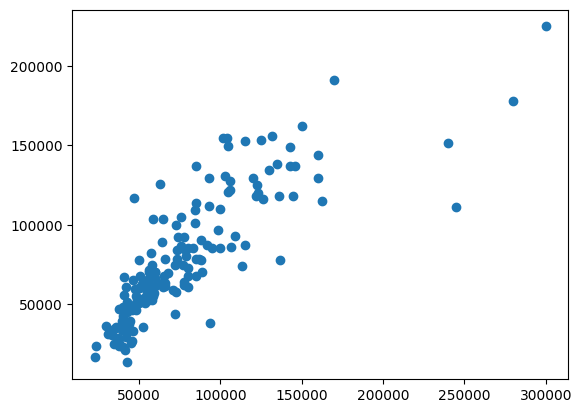

In [44]:
plt.scatter(y_test, y_pred)

**13) Feature Selection**

In [45]:
#Korelasyonu sıfıra en yakın olanlar aslında veriyi etkilemeyen kolonlardır ve bunları temizlemek daha iyi bir sonuç elde etmemize yardımcı olur

In [46]:
# Korelasyonu çok düşük (-0.14) olanları listeden çıkarıyoruz
X = df.drop(["Price", "Number of Ratings", "Number of Reviews"], axis=1)
y = df["Price"]

# Veriyi tekrar bölüyoruz (Ders 42 kuralı)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
print(r2_score(y_test, y_pred))

0.678037620224087


**14) Polinom Regresyon**

In [48]:
#Lineer Regresyon bildiğimiz gibi mantıksal olarak dümdüz bir doğruda ilerler ama hayat öyle dümdüz değildir maalesef.
#Örneğin sinemalarda satılan patlamış mısır, orada küçük boy ile büyük boy arasında sizce doğrusal bir artışmı vardır.
#Tabikide hayır. Çoğu şey doğrusal bir şekilde artmaz, hatta bazı durumlarda avantajsız olan daha pahalı bile olabilir.
#İşte bu yüzden biz Polinom Regresyon kullanırız.

In [49]:
#Dereceği ayarlarken abartmak Overfitting yani verinin trainleri Ezberlemesine yol açabiliriz ve bunu istemeyiz
#Overfitting nasıl anlaşılır? Eğer çizgimiz yılan gibi noktaları takip ediyorsa %100 Overfittinge sebebiyet vermiş oluruz.
#Overfittinge sebebiyet vermemek için için dikkat edilmesi gerekenler;
#Derece 1: Dümdüz bir çizgi(y = ax + b). Bu Lineer Regresyondur.
#Derece 2-3: Tatlı bir kavis. Genellikle gerçek dünya verileri için en idealidir.
#Derece 10 ve üstü: İşte burada çizgi yılan gibi toplara süzülür ve gerçek dışı sonuçlar açığa çıkar

In [50]:
from sklearn.preprocessing import PolynomialFeatures

# 1. Yamultma aracını tanımlıyoruz (Dereceyi 2 yaparak overfitting'den kaçıyoruz)
poly = PolynomialFeatures(degree=2)

# 2. X_train ve X_test verilerini bu yeni dereceye göre dönüştürüyoruz
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 3. Klasik Lineer Regresyon motorumuzu şimdi bu "yamulmuş" verilerle eğitiyoruz
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# 4. Başarıyı ölçüyoruz
y_pred_poly = poly_model.predict(X_test_poly)
print("Yeni Polinom R2 Skoru:", r2_score(y_test, y_pred_poly))

Yeni Polinom R2 Skoru: 0.47760965423454627


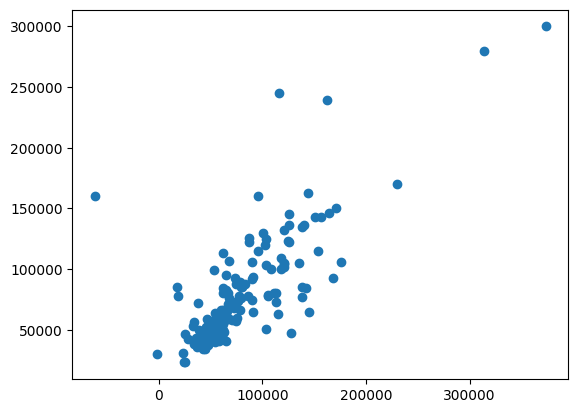

In [51]:
plt.scatter(y_pred_poly, y_test)

**15) Ridge & Lasso**

In [52]:
#Ridge Regresyon (L2): "Gürültüyü Kısan Ses Sistemi"

In [53]:
#Düşün ki bir odadasın ve 50 kişi aynı anda konuşuyor. Bazıları çok önemli şeyler söylüyor (RAM, SSD), bazıları ise sadece boş gürültü yapıyor (Marka_ASUS'un karesi ile HDD'nin çarpımı gibi saçma polinom sütunları).
#Mantık: Ridge, odadaki herkesin sesini (katsayılarını) orantılı olarak kısar.
#Hiç kimseyi tamamen susturmaz ama saçma sapan bağıranların (yüksek katsayılı gereksiz sütunların) etkisini minimize eder.
#Formüle bir ceza terimi ekler;

---

$\lambda \sum w^2$

---

In [54]:
#Lasso Regresyon (L1): "Acımasız Temizlikçi"

In [55]:
#Lasso biraz daha serttir. Odaya girer ve "Senin söylediklerin fiyatı tahmin etmek için yeterince önemli değil, sen tamamen sus!" der.
#Mantık: Lasso, önemsiz gördüğü sütunların katsayılarını tam olarak sıfıra (0) çeker.
#Yani aslında senin için otomatik olarak bir "özellik seçimi" yapmış olur.
#Gereksiz gördüğü 1900 tane polinom sütununu çöpe atar ve sadece asıl işe yarayanları bırakır.
#Matematik: Ceza terimi şöyledir;

---

$\lambda \sum |w|$

---

In [56]:
#Mutlak değer kullandığı için bazı katsayıları tam olarak sıfır yapma gücüne sahiptir.

In [57]:
from sklearn.linear_model import Ridge, Lasso

# 1. Ridge (Frenli Model)
ridge = Ridge(alpha=1) # Alpha, frenin sertliğidir.
ridge.fit(X_train_poly, y_train)
ridge_pred = ridge.predict(X_test_poly)
print("Ridge R2 Skoru:", r2_score(y_test, ridge_pred))

# 2. Lasso (Ayıklayıcı Model)
lasso = Lasso(alpha=100) # Lasso'da genellikle daha büyük bir alpha gerekir.
lasso.fit(X_train_poly, y_train)
lasso_pred = lasso.predict(X_test_poly)
print("Lasso R2 Skoru:", r2_score(y_test, lasso_pred))

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.83212e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Ridge R2 Skoru: 0.7277508550124259
Lasso R2 Skoru: 0.7364288163740746


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.483e+10, tolerance: 1.350e+08
  model = cd_fast.enet_coordinate_descent(


In [58]:
#Koddaki alpha nedir? onu hassasiyet ayarı olarak düşünebiliriz. Baynyodaki sıcak sığuk gibi.
#Düşük Alpha ise hassasiyet yüksektir. suyun aniden eksilere düşüp birden kaynaması gibi
#Yüksek Alpha ise hassasiyet düşüktür. musluğu istediğin kadar çevir su hep ılıktır( Underfitting )
#İdeal Alpha Suyun tam istediğin sıcaklıkta sabit kaldığı, ne çok sert ne çok gevşek olan o "tatlı nokta" (Sweet Spot).

In [59]:
#Peki bu tüm kodlarda standartmıdır? HAYIR. Bu koddan koda değişir ve deneme yanılma yöntemi ile çözülebilir.
#En basit yöntem budur. Bir liste yaparsın: [0.1, 1, 10, 100, 1000] ve her birini tek tek denersin. Hangi sayı en yüksek R2 skorunu veriyorsa "şampiyon odur" dersin

**16) Cross Validation**

In [60]:
from sklearn.linear_model import LassoCV

In [61]:
lassocv = LassoCV(cv=5)
lassocv.fit(X_train_poly, y_train)
lasso_pred = lassocv.predict(X_test_poly)
print("LassoCV R2 Skoru:", r2_score(y_test, lasso_pred))

LassoCV R2 Skoru: 0.3084027961843524


In [62]:
from sklearn.preprocessing import StandardScaler

# 1. Teraziyi (Scaler) kuruyoruz
scaler = StandardScaler()

# 2. Polinom verilerini aynı teraziye sokuyoruz
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

# 3. LassoCV'yi şimdi bu "eşitlenmiş" verilerle eğitiyoruz
lassocv = LassoCV(cv=5)
lassocv.fit(X_train_scaled, y_train)

# 4. Sonucu ölçüyoruz
y_pred_lasso = lassocv.predict(X_test_scaled)
print("Ölçeklenmiş LassoCV R2 Skoru:", r2_score(y_test, y_pred_lasso))

Ölçeklenmiş LassoCV R2 Skoru: 0.7133784773555784


In [63]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv=5)
ridgecv.fit(X_train_poly, y_train)
lasso_pred = ridgecv.predict(X_test_poly)
print("RidgeCV R2 Skoru:", r2_score(y_test, lasso_pred))

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.06456e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.50571e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.33829e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.84078e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.25606e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


RidgeCV R2 Skoru: 0.775904030288844


In [64]:
from sklearn.linear_model import ElasticNetCV
elasticnetcv = ElasticNetCV(cv=5)
elasticnetcv.fit(X_train_poly, y_train)
lasso_pred = elasticnetcv.predict(X_test_poly)
print("ElasticNetCV R2 Skoru:", r2_score(y_test, lasso_pred))

ElasticNetCV R2 Skoru: 0.2783830519637962
